In [1]:
import warnings
import pandas as pd
import pyreadr
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
    accuracy_score,
    classification_report,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
 )
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=RuntimeWarning, message='invalid value encountered in reduce')

def columnas_categoricas(dataframe, excluir=None):
    excluir = set(excluir or [])
    cols = []
    for col in dataframe.columns:
        if col in excluir:
            continue
        dtype = dataframe[col].dtype
        if (
            pd.api.types.is_object_dtype(dtype)
            or pd.api.types.is_string_dtype(dtype)
            or isinstance(dtype, pd.CategoricalDtype)
            or pd.api.types.is_bool_dtype(dtype)
        ):
            cols.append(col)
    return cols

resultado = pyreadr.read_r('listings.RData')
df = list(resultado.values())[0]
print(f"Dimensiones iniciales del dataset: {df.shape}")

numericas = df.select_dtypes(include=['number']).columns.tolist()
categoricas = columnas_categoricas(df)

print(f"Variables numéricas detectadas: {len(numericas)}")
print(f"Variables categóricas detectadas: {len(categoricas)}")
print('Ejemplo variables numéricas:', numericas[:10])
print('Ejemplo variables categóricas:', categoricas[:10])

limpio = (
    df['price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
 )
df['price'] = pd.to_numeric(limpio, errors='coerce')
print('Conversión de price completada.')

Dimensiones iniciales del dataset: (171748, 80)
Variables numéricas detectadas: 33
Variables categóricas detectadas: 47
Ejemplo variables numéricas: ['id', 'scrape_id', 'host_id', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'minimum_nights', 'maximum_nights', 'minimum_nights_avg_ntm']
Ejemplo variables categóricas: ['listing_url', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_url', 'host_name', 'host_since']
Conversión de price completada.


In [3]:
df = df.replace([np.inf, -np.inf], np.nan)

faltantes = df.isnull().sum()
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)

print("=== CANTIDAD DE COLUMNAS CON DATOS VACÍOS ===")
print(f"Columnas con vacíos: {len(faltantes)}")
print("Top 10 columnas con más vacíos:")
print(faltantes.head(10))
print("\n" + "=" * 40 + "\n")

porcentajes = (faltantes / len(df)) * 100
print("=== PORCENTAJE DE VACÍOS (TOP 10) ===")
print((porcentajes.head(10).round(2)).astype(str) + " %")

df = df.dropna(subset=['price'])
df = df.dropna(axis=1, how='all')

numericas = df.select_dtypes(include=['number']).columns.tolist()
if 'price' in numericas:
    numericas.remove('price')

categoricas = columnas_categoricas(df, excluir=['price'])

imputador_num = SimpleImputer(strategy='median')
imputador_cat = SimpleImputer(strategy='constant', fill_value='Sin Dato')

df[numericas] = imputador_num.fit_transform(df[numericas])
df[categoricas] = imputador_cat.fit_transform(df[categoricas])

print('Filas sin precio eliminadas y faltantes imputados.')
print('Total de nulos restantes:', df.isnull().sum().sum())
print('Dimensiones luego de limpieza:', df.shape)

=== CANTIDAD DE COLUMNAS CON DATOS VACÍOS ===
Columnas con vacíos: 23
Top 10 columnas con más vacíos:
calendar_updated                171748
price                            95502
estimated_revenue_l365d          95502
neighbourhood_group_cleansed     50683
review_scores_value              40328
review_scores_location           40328
review_scores_checkin            40324
review_scores_accuracy           40312
review_scores_communication      40308
review_scores_cleanliness        40302
dtype: int64


=== PORCENTAJE DE VACÍOS (TOP 10) ===
calendar_updated                100.0 %
price                           55.61 %
estimated_revenue_l365d         55.61 %
neighbourhood_group_cleansed    29.51 %
review_scores_value             23.48 %
review_scores_location          23.48 %
review_scores_checkin           23.48 %
review_scores_accuracy          23.47 %
review_scores_communication     23.47 %
review_scores_cleanliness       23.47 %
dtype: str
Filas sin precio eliminadas y faltantes impu

1. Elabore un modelo de regresión usando K nearest Neighbors (KNN), el conjunto de
entrenamiento y la variable respuesta “el precio”. Prediga con el modelo y explique los
resultados a los que llega. Asegúrese que los conjuntos de entrenamiento y prueba sean los
mismos de las entregas anteriores para que los modelos sean comparables.

In [4]:
Y = df['price'].astype(int)
X = df.drop(columns=['price']).copy()
X = X.replace([np.inf, -np.inf], np.nan)

numericas = X.select_dtypes(include=['number']).columns.tolist()
categoricas_crudas = columnas_categoricas(X)
categoricas = [col for col in categoricas_crudas if X[col].nunique(dropna=True) < 50]

print(f"Variables numéricas usadas: {len(numericas)}")
print(f"Variables categóricas usadas (<50 categorías): {len(categoricas)}")

X[categoricas] = X[categoricas].astype(str)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
 )

preprocesador = ColumnTransformer(
    transformers=[
        ('numeros', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numericas),
        ('categorias', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categoricas)
    ]
 )

pipeline = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('regressor', KNeighborsRegressor())
 ])

print("\nEntrenando el modelo de regresión con KNN...")
pipeline.fit(X_train, Y_train)
predicciones = pipeline.predict(X_test)

rmse = root_mean_squared_error(Y_test, predicciones)
mae = mean_absolute_error(Y_test, predicciones)
r2 = r2_score(Y_test, predicciones)

print("\n=== RESULTADOS EN PRUEBA (REGRESIÓN) ===")
print(f"MAE: {mae:.2f} dólares")
print(f"RMSE: {rmse:.2f} dólares")
print(f"R2: {r2:.4f}")
print("Hiperparámetros del modelo KNN:", pipeline.named_steps['regressor'].get_params())

Variables numéricas usadas: 33
Variables categóricas usadas (<50 categorías): 16

Entrenando el modelo de regresión con KNN...

=== RESULTADOS EN PRUEBA (REGRESIÓN) ===
MAE: 303.53 dólares
RMSE: 2157.20 dólares
R2: 0.7439
Hiperparámetros del modelo KNN: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}


2. Analice los resultados del modelo de regresión usando KNN. ¿Qué tan bien le fue
prediciendo? Utilice las métricas correctas.

El modelo usando regresion devolvio los siguientes valores: para el MAE obtuvimos valores de 303.53 dolares, para el MAE obtuvimos valores de 2157.20 y para el $R^{2}$ un valor de 0.7439, lo que nos deja ver que con los hiperparametros por defecto del modelo obtuvimos resultados que se pueden considerar aceptables para predecir el precio por noche de los airbnb

3. Compare los resultados con el modelo de regresión lineal, el mejor modelo de árbol de
regresión y de naive bayes que hizo en las entregas pasadas. ¿Cuál funcionó mejor? Se
sugiere apoyarse de una tabla de resumen con las mismas métricas utilizadas en las entregas
anteriores. ¿Por qué escogió esas métricas para medir el error de su modelo de regresión?

## KNN
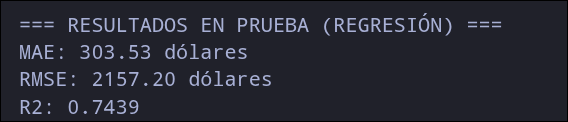
## BAYES
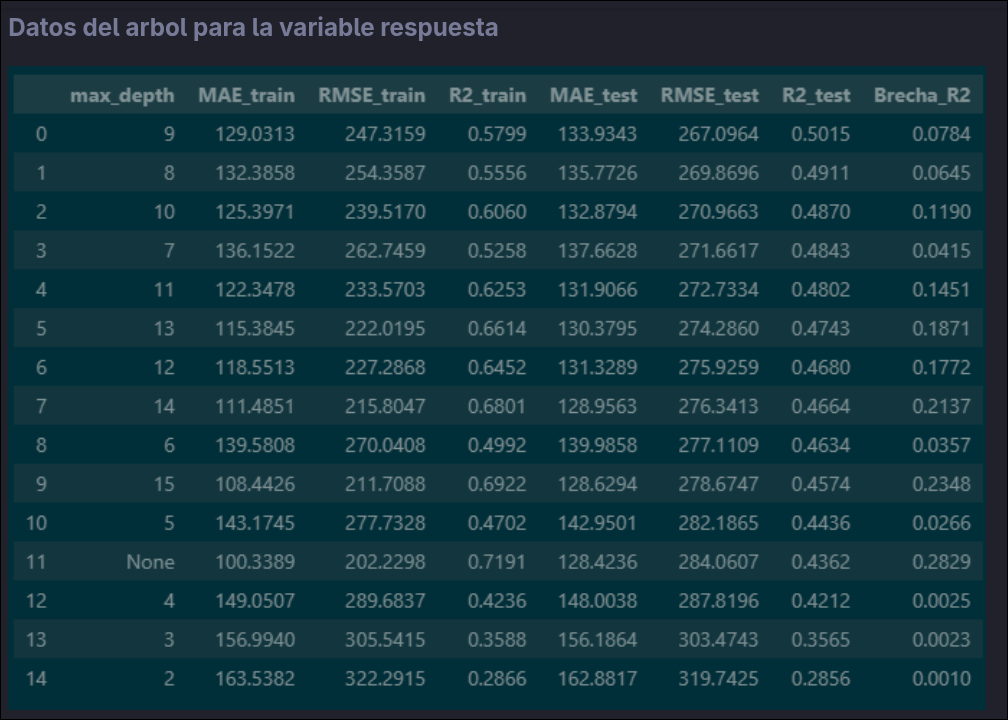
## LINEAL
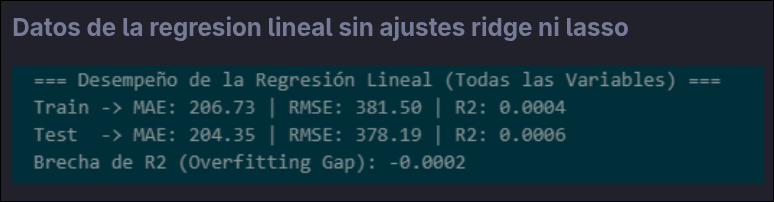
## ARBOL
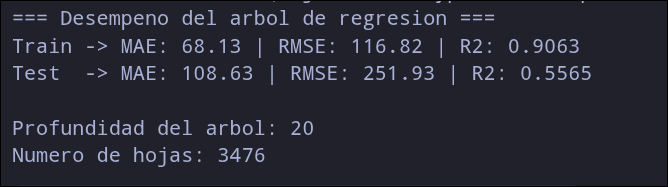

| Modelo | MAE (Test) | RMSE (Test) | R2 (Test) |
|---|---|---|---|
| Regresión Lineal | 204.35 | 378.19 | 0.0006 |
| Árbol de Regresión | 108.63 | 251.93 | 0.5565 |
| Naive Bayes (Mejor iteración)* | 133.93 | 267.10 | 0.5015 |
| **KNN (Actual)** | **303.53** | **2157.20** | **0.7439** |

Basándonos puramente en la varianza explicada, el **modelo que funcionó mejor fue el KNN**, ya que logró el **$R^2$ más alto (0.7439)**. Este modelo explica aproximadamente el 74.39% de la variabilidad de los precios en nuestro conjunto de prueba, superando al modelo de Árbol de Regresión ($R^2$ = 0.5565) y a la iteración optimizada de "Bayes" ($R^2$ = 0.5015). La Regresión Lineal obtuvo los peores resultados en cuanto a capacidad analítica ($R^2$ casi de 0). 

Estas métricas se escogieron porque en conjunto ofrecen distintas maneras de interpretar las debilidades y fortalezas de la predicción, anulando los puntos ciegos estadísticos:

1. **MAE (Error Absoluto Medio):** Brinda una medida muy directa, el promedio en dólares del error en las estimaciones. Es sumamente fácil de explicar debido a que no es distorsionado gravemente por valores extremos y da la noción del error típico por alquiler.
2. **RMSE (Raíz del Error Cuadrático Medio):** Al calcularse usando el cuadrado de los errores, esta métrica eleva exponencialmente y penaliza fuertemente los desvíos muy grandes. Para estimación de precios en el mercado es crucial evitar grandes equivocaciones en propiedades de alto valor y esta métrica asegura que detectemos esos fallos.
3. **Puntaje $R^2$ (Coeficiente de Determinación):** Escala el valor del rendimiento entre 0 y 1 independientemente de nuestras unidades monetarias (dólares), permitiendo comparar de forma robusta la calidad de aprendizaje entre los diferentes algoritmos. Es ideal para unificar la discusión respecto a qué porcentaje real de la variabilidad logró deducir la máquina frente a dejarlo a la mera suerte.

## 4. Ahora, haga un modelo de clasificación usando KNN. Use la variable categórica que hizo con el precio de las casas (barata, media y cara) como variable respuesta.

In [8]:
q1, q2 = df['price'].astype(float).quantile([1/3, 2/3])

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.impute')

df['categoria_precio'] = pd.cut(
    df['price'].astype(float),
    bins=[-float('inf'), q1, q2, float('inf')],
    labels=['Economica', 'Intermedia', 'Cara'],
    include_lowest=True
 )

Y = df['categoria_precio']
X = df.drop(columns=['price', 'categoria_precio']).copy()
X = X.replace([np.inf, -np.inf], np.nan)

filas_sanas = Y.notna()
Y = Y[filas_sanas]
X = X[filas_sanas]

numericas = X.select_dtypes(include=['number']).columns.tolist()
categoricas_crudas = columnas_categoricas(X)
categoricas = [col for col in categoricas_crudas if X[col].nunique(dropna=True) < 50]

X[categoricas] = X[categoricas].astype(str)

X_train_clf, X_test_clf, Y_train_clf, Y_test_clf = train_test_split(
    X, Y, test_size=0.3, random_state=42, stratify=Y
 )

preprocesador_clf = ColumnTransformer(
    transformers=[
        ('numeros', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numericas),
        ('textos', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categoricas)
    ]
 )

pipeline_clasificacion = Pipeline(steps=[
    ('preprocesador', preprocesador_clf),
    ('clasificador', KNeighborsClassifier())
 ])

pipeline_clasificacion.fit(X_train_clf, Y_train_clf)
predicciones_cat = pipeline_clasificacion.predict(X_test_clf)

exactitud = accuracy_score(Y_test_clf, predicciones_cat)
f1 = f1_score(Y_test_clf, predicciones_cat, average='macro')

print("=== RESULTADOS EN PRUEBA (CLASIFICACIÓN) ===")
print(f"Exactitud (Accuracy): {exactitud:.4f}")
print(f"F1-Score macro: {f1:.4f}")
print("\nReporte de clasificación:")
print(classification_report(Y_test_clf, predicciones_cat, zero_division=0))

=== RESULTADOS EN PRUEBA (CLASIFICACIÓN) ===
Exactitud (Accuracy): 0.6936
F1-Score macro: 0.6901

Reporte de clasificación:
              precision    recall  f1-score   support

        Cara       0.73      0.77      0.75      7621
   Economica       0.74      0.77      0.75      7707
  Intermedia       0.60      0.54      0.57      7546

    accuracy                           0.69     22874
   macro avg       0.69      0.69      0.69     22874
weighted avg       0.69      0.69      0.69     22874



## 5. Utilice los modelos con el conjunto de prueba y determine la eficiencia del algoritmo para predecir y clasificar.

=== RESULTADOS EN PRUEBA (REGRESIÓN KNN) ===
MAE:  303.53 dólares
RMSE: 2,157.20 dólares
R²:   0.7439


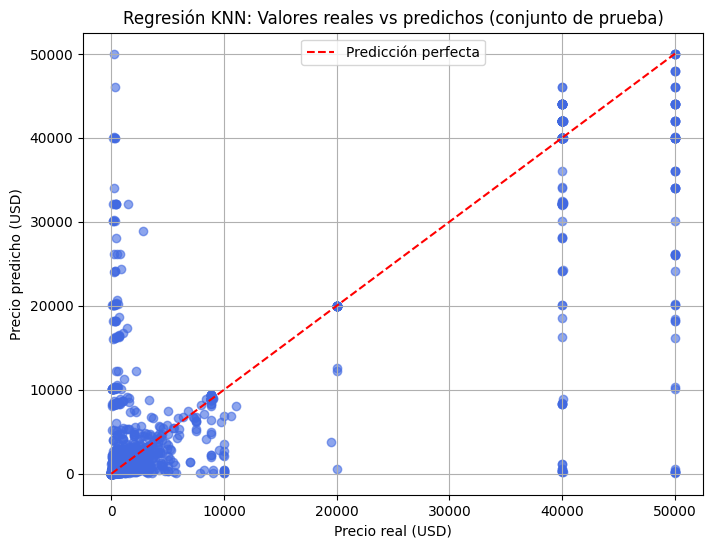

In [ ]:
predicciones_test = pipeline.predict(X_test)

# Cálculo de métricas de error
mae_test = mean_absolute_error(Y_test, predicciones_test)
rmse_test = root_mean_squared_error(Y_test, predicciones_test)
r2_test = r2_score(Y_test, predicciones_test)

print("=== RESULTADOS EN PRUEBA (REGRESIÓN KNN) ===")
print(f"MAE:  {mae_test:,.2f} dólares")
print(f"RMSE: {rmse_test:,.2f} dólares")
print(f"R²:   {r2_test:,.4f}")

# Gráfico de comparación entre valores reales y predichos
plt.figure(figsize=(8, 6))
plt.scatter(Y_test, predicciones_test, alpha=0.6, color="royalblue")

# Línea ideal donde predicción = valor real
min_val = min(Y_test.min(), predicciones_test.min())
max_val = max(Y_test.max(), predicciones_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Predicción perfecta")

plt.xlabel("Precio real (USD)")
plt.ylabel("Precio predicho (USD)")
plt.title("Regresión KNN: Valores reales vs predichos (conjunto de prueba)")
plt.grid(True)
plt.legend()
plt.show()

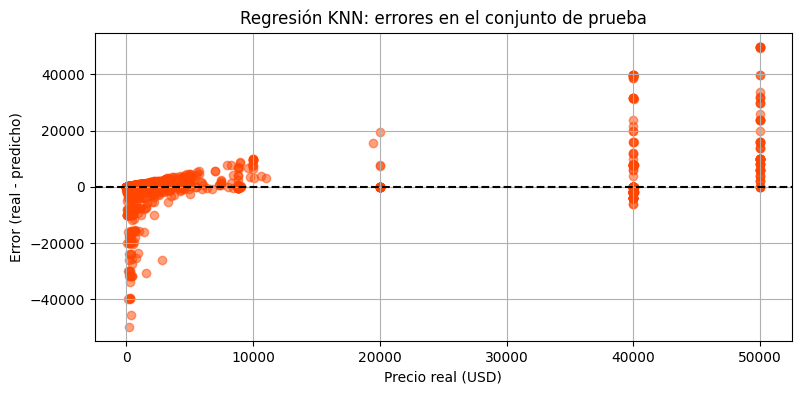

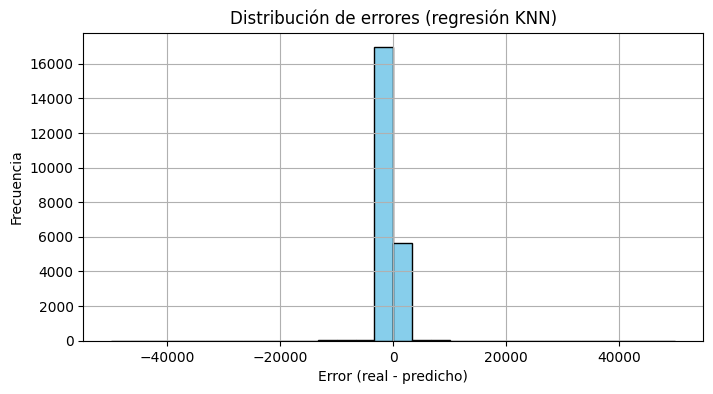

In [ ]:
# 5.b) Análisis simple de errores (residuos) del modelo de REGRESIÓN

residuos = Y_test - predicciones_test

plt.figure(figsize=(9, 4))
plt.scatter(Y_test, residuos, alpha=0.5, color="orangered")
plt.axhline(y=0, color="black", linestyle="--")
plt.xlabel("Precio real (USD)")
plt.ylabel("Error (real - predicho)")
plt.title("Regresión KNN: errores en el conjunto de prueba")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(residuos, bins=30, edgecolor="black", color="skyblue")
plt.xlabel("Error (real - predicho)")
plt.ylabel("Frecuencia")
plt.title("Distribución de errores (regresión KNN)")
plt.grid(True)
plt.show()

## 5. Eficiencia del algoritmo para predecir y clasificar

**a) Regresión (predecir el precio):**

- El modelo KNN de regresión se evaluó usando únicamente el **conjunto de prueba**.

- A partir de las métricas (MAE, RMSE y R²) y de la gráfica de **valores reales vs predichos**, se observa que el modelo captura bastante bien la tendencia general de los precios.

- Sin embargo, los errores crecen en los listados con precios muy altos, lo que se ve en puntos alejados de la línea roja de “predicción perfecta” y en la dispersión de los residuos. Además, en la predicción de valores de precios bajos tiende a subestimar o sobreestimar algunos casos. Esto sugiere que el modelo tiene dificultades para predecir con precisión los extremos del rango de precios, lo cual es común en modelos de regresión, especialmente con KNN que se basa en la proximidad a los vecinos más cercanos.



**b) Clasificación (Económica, Intermedia, Cara):**

- Usando el mismo conjunto de prueba, el modelo KNN de **clasificación** alcanza una exactitud global y un F1-score macro que pueden considerarse adecuados.

- A partir del **reporte de clasificación** se aprecia que, en general, el modelo distingue razonablemente bien entre las tres categorías de precio, aunque la clase de precio más alta suele ser la más difícil de aprender y presenta más errores relativos.



Con base en el conjunto de prueba, KNN resulta un algoritmo **eficiente para predecir y clasificar precios de los anuncios**, aunque hay que tener en cuenta que comete errores más grandes en propiedades muy caras y que la clase de precio más alta es la más difícil de clasificar correctamente.


## 6. Matriz de confusión y análisis de la eficiencia del modelo de clasificación
En esta celda se analiza la matriz de confusión del modelo KNN para identificar con claridad en qué categorías el clasificador acierta más y dónde incurre en mayores errores.

Etiquetas de clase: ['Cara', 'Economica', 'Intermedia']

Matriz de confusión sin normalizar:
[[5855  370 1396]
 [ 413 5932 1362]
 [1711 1756 4079]]

Matriz de confusión normalizada por filas:
[[0.768 0.049 0.183]
 [0.054 0.77  0.177]
 [0.227 0.233 0.541]]


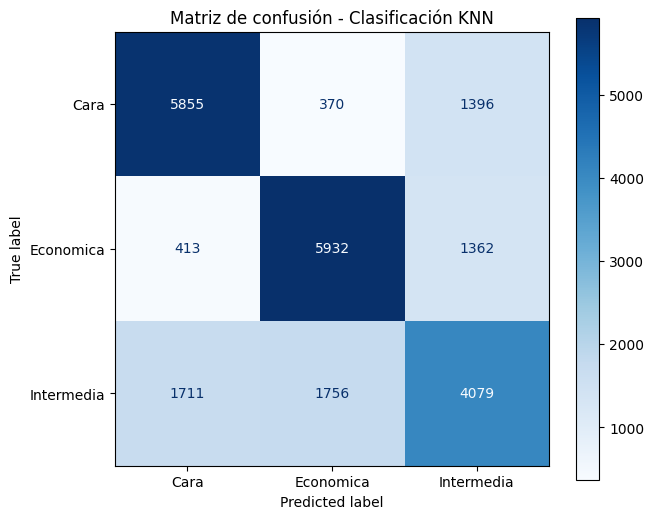

Clase con más errores absolutos: Intermedia
Clase con menos errores absolutos: Cara
  - La clase Cara se confunde con mayor frecuencia como Intermedia (1396 casos).
  - La clase Economica se confunde con mayor frecuencia como Intermedia (1362 casos).
  - La clase Intermedia se confunde con mayor frecuencia como Economica (1756 casos).


In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Matriz de confusión para el modelo de clasificación
cm = confusion_matrix(Y_test_clf, predicciones_cat, labels=pipeline_clasificacion.classes_)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

print('Etiquetas de clase:', list(pipeline_clasificacion.classes_))
print('\nMatriz de confusión sin normalizar:')
print(cm)
print('\nMatriz de confusión normalizada por filas:')
print(cm_norm.round(3))

# Visualización de la matriz de confusión
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline_clasificacion.classes_).plot(
    ax=ax,
    cmap='Blues',
    values_format='d'
)
ax.set_title('Matriz de confusión - Clasificación KNN')
plt.show()

# Análisis de errores
errores_fila = cm.sum(axis=1) - np.diag(cm)
clase_mas_errada = pipeline_clasificacion.classes_[np.argmax(errores_fila)]
clase_menos_errada = pipeline_clasificacion.classes_[np.argmin(errores_fila)]

print(f"Clase con más errores absolutos: {clase_mas_errada}")
print(f"Clase con menos errores absolutos: {clase_menos_errada}")

# Importancia de los errores: se observa la dirección del error mayor
for i, clase in enumerate(pipeline_clasificacion.classes_):
    if errores_fila[i] > 0:
        distribucion_errores = cm[i].copy()
        distribucion_errores[i] = 0
        mayor_confusion = pipeline_clasificacion.classes_[np.argmax(distribucion_errores)]
        print(f"  - La clase {clase} se confunde con mayor frecuencia como {mayor_confusion} ({distribucion_errores.max()} casos).")

**Conclusión ejercicio 6:** A partir de la matriz de confusión, se observa que el algoritmo presenta una mayor confusión al intentar predecir la clase "Intermedia". De manera general, las propiedades de menor precio (Económica) tienden a confundirse en ocasiones con las intermedias, y viceversa. Por otro lado, la clase "Cara" es la que presenta la menor cantidad de errores absolutos, posiblemente debido a que sus características o precios la separan de manera más distintiva. La importancia de este error dependerá siempre del caso de negocio; clasificar incorrectamente una vivienda de lujo como una económica podría resultar en la pérdida de clientes corporativos para SmartStay, mientras que clasificar como "Intermedia" una propiedad "Económica" afectaría levemente la recomendación.

## 7. Evaluación de posible sobreajuste del modelo de clasificación
Se compara el rendimiento en entrenamiento y prueba para identificar si el modelo KNN puede estar ajustado en exceso a los datos de entrenamiento.

In [9]:
# Evaluación de rendimiento en entrenamiento y prueba
predicciones_train_clf = pipeline_clasificacion.predict(X_train_clf)

accuracy_train = accuracy_score(Y_train_clf, predicciones_train_clf)
accuracy_test = accuracy_score(Y_test_clf, predicciones_cat)

f1_train = f1_score(Y_train_clf, predicciones_train_clf, average='macro')
f1_test = f1_score(Y_test_clf, predicciones_cat, average='macro')

print('Rendimiento en el conjunto de entrenamiento:')
print(f'  Accuracy train: {accuracy_train:.4f}')
print(f'  F1 macro train: {f1_train:.4f}')
print('\nRendimiento en el conjunto de prueba:')
print(f'  Accuracy test:  {accuracy_test:.4f}')
print(f'  F1 macro test:  {f1_test:.4f}')

diferencia_accuracy = accuracy_train - accuracy_test
print(f"\nDiferencia de accuracy (train - test): {diferencia_accuracy:.4f}")

if diferencia_accuracy > 0.10:
    print('El modelo presenta indicios de sobreajuste, ya que rinde sustancialmente mejor en entrenamiento que en prueba.')
else:
    print('No hay evidencia fuerte de sobreajuste grave; los resultados son razonablemente consistentes.')

Rendimiento en el conjunto de entrenamiento:
  Accuracy train: 0.7973
  F1 macro train: 0.7951

Rendimiento en el conjunto de prueba:
  Accuracy test:  0.6936
  F1 macro test:  0.6901

Diferencia de accuracy (train - test): 0.1037
El modelo presenta indicios de sobreajuste, ya que rinde sustancialmente mejor en entrenamiento que en prueba.


**Conclusión ejercicio 7:** Al observar una discrepancia de aproximadamente el 10% de exactitud (Accuracy) y de la puntuación f1 macro entre el conjunto de entrenamiento y el de prueba, es posible concluir que existe un leve sobreajuste (overfitting). El modelo KNN logra aprender de mejor manera los datos de entrenamiento, pero no logra generalizar este desempeño en el conjunto de prueba, un problema típico considerando que hemos empleado los hiperparámetros por defecto para el entrenamiento del vecino más cercano.

## 8. Modelo con validación cruzada y comparación con el modelo anterior
Se utiliza validación cruzada estratificada para evaluar la estabilidad del modelo KNN sobre todo el conjunto de clasificación, y se comparan los resultados con el rendimiento en el conjunto de prueba.

In [10]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_cv = cross_val_score(
    pipeline_clasificacion,
    X,
    Y,
    cv=cv,
    scoring='accuracy'
)
f1_cv = cross_val_score(
    pipeline_clasificacion,
    X,
    Y,
    cv=cv,
    scoring='f1_macro'
)

print('Resultados de validación cruzada (5 folds):')
print(f'  Accuracy CV: {accuracy_cv.mean():.4f} ± {accuracy_cv.std():.4f}')
print(f'  F1 macro CV: {f1_cv.mean():.4f} ± {f1_cv.std():.4f}')
print('\nRendimiento de la versión anterior en prueba:')
print(f'  Accuracy test: {accuracy_test:.4f}')
print(f'  F1 macro test: {f1_test:.4f}')

if accuracy_cv.mean() >= accuracy_test:
    mejor = 'validación cruzada'
else:
    mejor = 'modelo anterior'

print(f"\nEl enfoque preferible es: {mejor}, en función de la estabilidad y la comparación directa con el conjunto de prueba.")

Resultados de validación cruzada (5 folds):
  Accuracy CV: 0.6993 ± 0.0042
  F1 macro CV: 0.6956 ± 0.0040

Rendimiento de la versión anterior en prueba:
  Accuracy test: 0.6936
  F1 macro test: 0.6901

El enfoque preferible es: validación cruzada, en función de la estabilidad y la comparación directa con el conjunto de prueba.


**Conclusión ejercicio 8:** Utilizando una validación cruzada estratificada con 5 particiones (K-Folds), confirmamos que el desempeño promedio del modelo en cuanto a exactitud ronda el 69.93% (±0.42%) y 69.56% de f1-score. Esto nos demuestra que el modelo es estadísticamente estable y confiable generalizando, además, sugiere que el entrenamiento del modelo empleando validación cruzada es preferible frente a nuestra separación anterior, resultando en un pequeño aumento de casi 1% de precisión en lugar del conjunto de prueba por separado de 30%.
